In [1]:
from msisim.test import Tissue, Grid, types_stripes, types_random_field, types_checkerboard, Composition, k_for_consumption, GaussianBeam, RasterScan, simulate_raster, scan_extent
import matplotlib.pyplot as plt

import numpy as np

<Axes: xlabel='$x$ ($\\mu$m)', ylabel='$y$ ($\\mu$m)'>

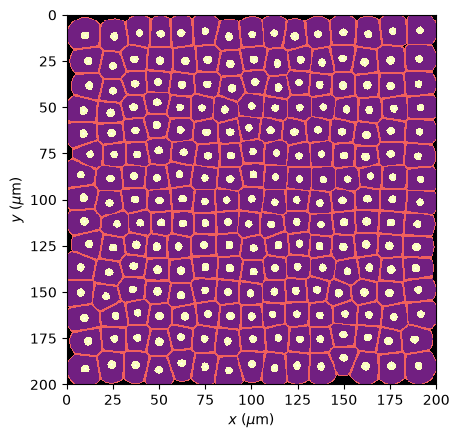

In [ ]:
grid = Grid.from_extent(200, 200, dx=0.5) #dx should be much smaller than beam sigma
tissue = Tissue.jittered_lattice(grid, (12.5, 12.5), jitter=0.12, lloyd_iters=2, seed=16)
tissue.show()


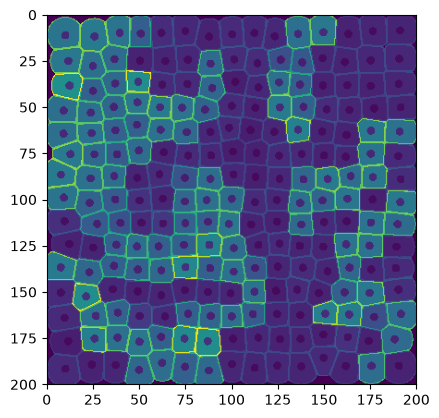

In [7]:

types = types_random_field(
    tissue=tissue,
    correlation_um=10,
    proportions=[0.5, 0.5],
)

comp = Composition(
    species=["PC 34:1", "PC 38:4"],
    type_means= [
                [1.0, 0.3],        # species 0 in type 0, type 1
                [0.2, 0.8]],       # species 1

    compartment_weights=[[1.0, 2.0, 0.3], [1.0, 1.5, 0.3]],
    cell_cv=0.15,
)
rho0 = comp.render(tissue, types, seed=1)

plt.imshow(rho0[0], extent=grid.extent)

x pitch: 20.0, y pitch: 20, beam fwhm: (np.float64(11.774100225154747), np.float64(11.774100225154747))
x linescan (um): 160.0, x linescan (um): 160 


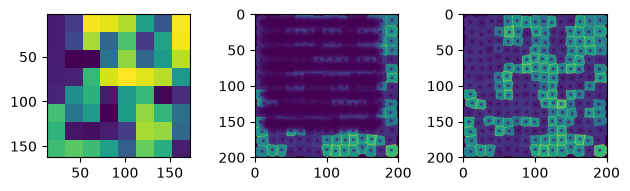

In [10]:

beam = GaussianBeam(sigma_x=5, sigma_y=5, I0=1e4)

scan = RasterScan.from_timing(x_start=12.5, y_start=12.5, n_pix=8, n_lines=8, velocity=200, t_sampling=0.1, pixel_y=20,)

print(f"x pitch: {scan.pixel_x}, y pitch: {scan.pixel_y}, beam fwhm: {beam.fwhm()}")
print(f"x linescan (um): {scan.pixel_x * scan.n_pix}, x linescan (um): {scan.pixel_y * scan.n_lines} ")


k = k_for_consumption(0.99, beam, scan)


img, rho = simulate_raster(rho0, grid, beam, scan, k=k)


fig, axs = plt.subplots(1,3)
axs[0].imshow(img[1,:,:], extent=scan_extent(scan)) 
axs[1].imshow(rho[1,:,:], extent=grid.extent)
axs[2].imshow(rho0[1],  extent=grid.extent)

plt.tight_layout()

x pitch: 10.0, y pitch: 10, beam fwhm: (np.float64(11.774100225154747), np.float64(11.774100225154747))
x linescan (um): 170.0, x linescan (um): 170 


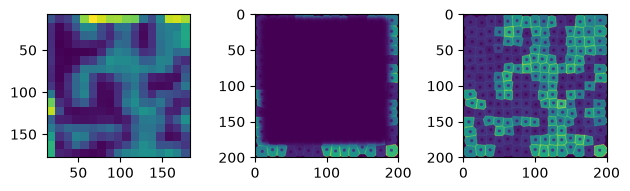

In [8]:

beam = GaussianBeam(sigma_x=5, sigma_y=5, I0=1e4)

scan = RasterScan.from_timing(x_start=12.5, y_start=12.5, n_pix=17, n_lines=17, velocity=100, t_sampling=0.1, pixel_y=10,)

print(f"x pitch: {scan.pixel_x}, y pitch: {scan.pixel_y}, beam fwhm: {beam.fwhm()}")
print(f"x linescan (um): {scan.pixel_x * scan.n_pix}, x linescan (um): {scan.pixel_y * scan.n_lines} ")


k = k_for_consumption(0.99, beam, scan)


img, rho = simulate_raster(rho0, grid, beam, scan, k=k)


fig, axs = plt.subplots(1,3)
axs[0].imshow(img[1,:,:], extent=scan_extent(scan)) 
axs[1].imshow(rho[1,:,:], extent=grid.extent)
axs[2].imshow(rho0[1],  extent=grid.extent)

plt.tight_layout()

x pitch: 5.0, y pitch: 5, beam fwhm: (np.float64(11.774100225154747), np.float64(11.774100225154747))
x linescan (um): 175.0, x linescan (um): 175 


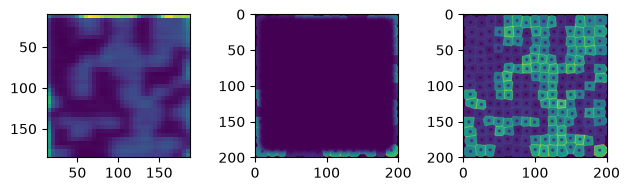

In [9]:

beam = GaussianBeam(sigma_x=5, sigma_y=5, I0=1e4)

scan = RasterScan.from_timing(x_start=12.5, y_start=12.5, n_pix=35, n_lines=35, velocity=50, t_sampling=0.1, pixel_y=5,)

print(f"x pitch: {scan.pixel_x}, y pitch: {scan.pixel_y}, beam fwhm: {beam.fwhm()}")
print(f"x linescan (um): {scan.pixel_x * scan.n_pix}, x linescan (um): {scan.pixel_y * scan.n_lines} ")


k = k_for_consumption(0.99, beam, scan)


img, rho = simulate_raster(rho0, grid, beam, scan, k=k)


fig, axs = plt.subplots(1,3)
axs[0].imshow(img[1,:,:], extent=scan_extent(scan)) 
axs[1].imshow(rho[1,:,:], extent=grid.extent)
axs[2].imshow(rho0[1],  extent=grid.extent)

plt.tight_layout()

x pitch: 1.0, y pitch: 1, beam fwhm: (np.float64(2.3548200450309493), np.float64(2.3548200450309493))
x linescan (um): 175.0, x linescan (um): 175 


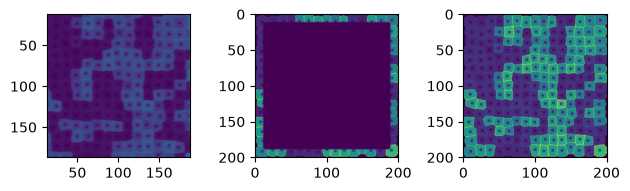

In [10]:

beam = GaussianBeam(sigma_x=1, sigma_y=1, I0=1e4)

scan = RasterScan.from_timing(x_start=12.5, y_start=12.5, n_pix=35 * 5, n_lines=35 * 5, velocity=10, t_sampling=0.1, pixel_y=1,)


print(f"x pitch: {scan.pixel_x}, y pitch: {scan.pixel_y}, beam fwhm: {beam.fwhm()}")
print(f"x linescan (um): {scan.pixel_x * scan.n_pix}, x linescan (um): {scan.pixel_y * scan.n_lines} ")


k = k_for_consumption(0.99, beam, scan)


img, rho = simulate_raster(rho0, grid, beam, scan, k=k)


fig, axs = plt.subplots(1,3)

axs[0].imshow(img[1,:,:], extent=scan_extent(scan)) 
axs[1].imshow(rho[1,:,:], extent=grid.extent)
axs[2].imshow(rho0[1],  extent=grid.extent)

plt.tight_layout()

plt.tight_layout()